# Task 1: Data Preparation

### Approach

The Breast Cancer dataset was loaded from a CSV file into a Pandas DataFrame for analysis. The dataset structure was explored by examining its dimensions, data types, and feature names to understand the available information. Data quality checks were then performed to identify missing values and duplicate records, ensuring the dataset was clean before model training.

Since the `Unnamed: 0` column represents only an index and does not contribute to prediction, it was removed from the dataset. The target variable (`y`) was separated from the predictor variables to prepare the data for machine learning.

Finally, feature scaling was applied using **StandardScaler**. K-Nearest Neighbors (KNN) is a distance-based algorithm that relies on Euclidean distance to identify the nearest neighbors. Features with larger numerical ranges can dominate the distance calculation and bias the model. Standardization transforms each feature to have a mean of 0 and a standard deviation of 1, ensuring that all features contribute equally during classification and improving the overall performance of the KNN classifier.

In [4]:
# Import required libraries
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("brca.csv")

# Explore dataset
print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove unnecessary index column (if present)
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first five rows
print("\nScaled Features:")
print(X_scaled.head())

Shape of Dataset: (569, 32)

Column Names:
Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

Data Types:
Unnamed: 0               int64
x.radius_mean          float64
x.texture_mean         float64
x.perimeter_mean       float64
x.area_mean            float64
x.smoothness_mean      float64
x.compactness_mean     float64
x.concavity_mean       float64
x.conc

# Task 2: Train-Test Split Analysis

### Approach

The preprocessed dataset was divided into training and testing sets using three different train-test split ratios: **80:20**, **70:30**, and **90:10**. For each split, a K-Nearest Neighbors (KNN) classifier with the default value of **k = 5** was trained and evaluated using the testing data.

The classification accuracy obtained from each split was compared to analyze the effect of different amounts of training data on model performance. Increasing the training set generally allows the model to learn better patterns, whereas increasing the testing set provides a more reliable estimate of model performance. Comparing multiple train-test splits helps evaluate the stability, robustness, and generalization capability of the classifier before selecting an optimal configuration.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Different train-test split ratios
split_ratios = [
    (0.20, "80:20"),
    (0.30, "70:30"),
    (0.10, "90:10")
]

results = []

for test_size, ratio in split_ratios:

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Train KNN model
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Predictions
    y_pred = knn.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results.append([ratio, X_train.shape[0], X_test.shape[0], accuracy])

# Display comparison table
results_df = pd.DataFrame(
    results,
    columns=["Train : Test Split", "Training Samples", "Testing Samples", "Accuracy"]
)

print(results_df)

  Train : Test Split  Training Samples  Testing Samples  Accuracy
0              80:20               455              114  0.956140
1              70:30               398              171  0.964912
2              90:10               512               57  0.964912


# Task 3: KNN Model with Heuristic K Selection

## 3.1 Heuristic Method for K Selection

### Approach

The initial value of **K** was selected using the heuristic rule
where **n** is the number of training samples. This heuristic provides a reasonable starting point for selecting the number of nearest neighbors while reducing the likelihood of overfitting or underfitting.

The heuristic K value was used as the baseline, and additional models were trained using neighboring values (**K − 5** to **K + 5**) to determine the optimal K based on classification accuracy.
## 3.2 Model Training

### Approach

Multiple KNN classifiers were trained using different values of **K** around the heuristic value. The accuracy of each model was calculated using the testing dataset, and an accuracy-versus-K graph was plotted. The K value that produced the highest testing accuracy was selected as the optimal K for the dataset.
## 3.3 Distance Matrix and Decision Boundary Mapping

### Euclidean Distance

Euclidean distance calculates the straight-line distance between two data points in the feature space.
It is suitable for continuous numerical data after feature scaling and is the default distance metric used by the KNN algorithm.

### Manhattan Distance

Manhattan distance calculates the distance by summing the absolute differences between feature values.

It is suitable for datasets containing high-dimensional data or when movement occurs only along horizontal and vertical directions. Manhattan distance is generally less sensitive to outliers than Euclidean distance.
To visualize the effect of different K values, decision boundaries were plotted for **K = 1, 5, 10, and 20**. As K increases, the decision boundary becomes smoother, reducing model complexity and variance while increasing bias. Smaller K values create more irregular boundaries that closely follow the training data and may lead to overfitting.

Training Samples: 455
Heuristic K = 21
   K Value  Accuracy
0       17  0.938596
1       19  0.938596
2       21  0.938596
3       23  0.938596
4       25  0.947368

Optimal K = 25


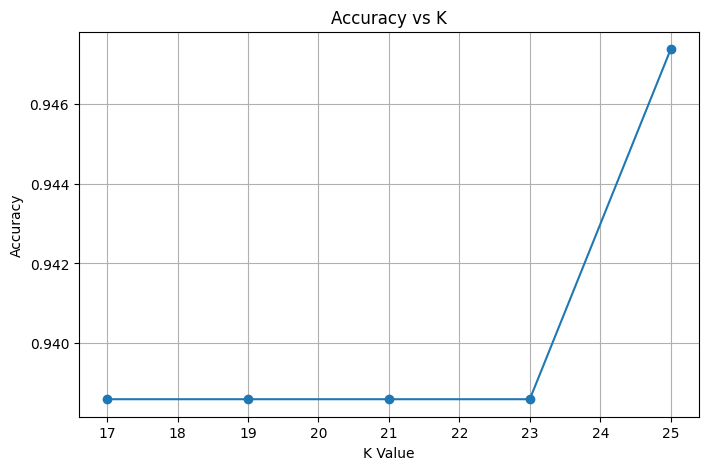

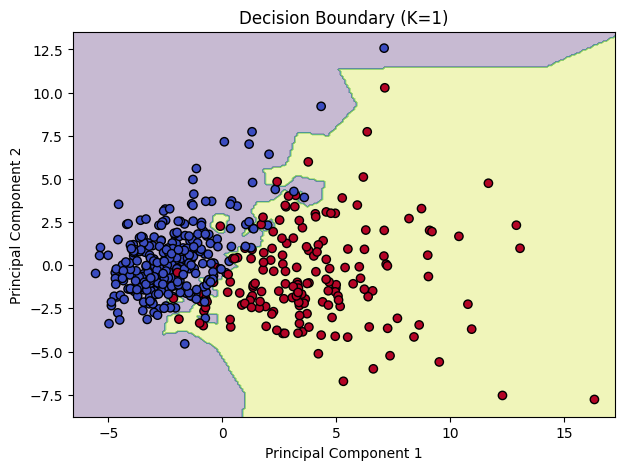

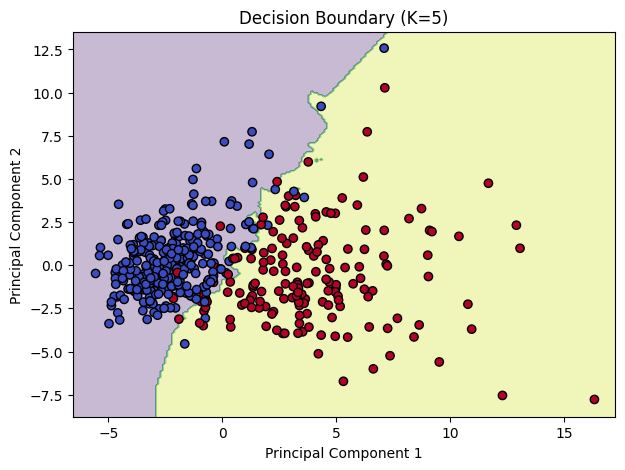

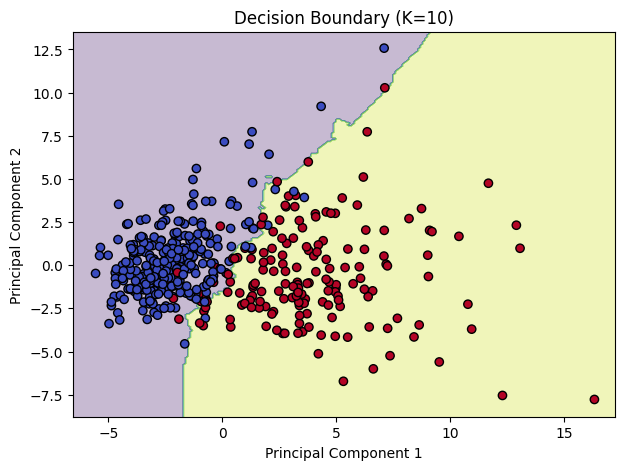

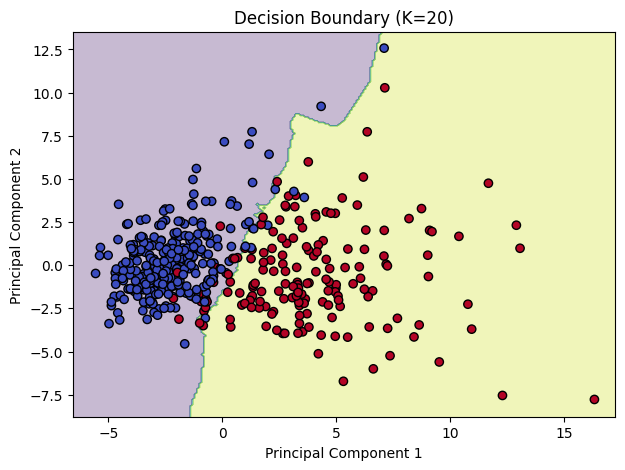

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# -----------------------------------------------------
# 3.1 Heuristic K Selection
# -----------------------------------------------------

# Use training data from the 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Heuristic K
heuristic_k = int(np.sqrt(len(X_train)))

# Ensure odd K
if heuristic_k % 2 == 0:
    heuristic_k += 1

print("Training Samples:", len(X_train))
print("Heuristic K =", heuristic_k)

# -----------------------------------------------------
# 3.2 Model Training
# -----------------------------------------------------

k_values = []

for k in range(max(1, heuristic_k-5), heuristic_k+6):
    if k % 2 != 0:
        k_values.append(k)

accuracy = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy.append(accuracy_score(y_test, y_pred))

# Accuracy table
result = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": accuracy
})

print(result)

# Best K
best_k = k_values[np.argmax(accuracy)]

print("\nOptimal K =", best_k)

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# 3.3 Decision Boundary
# -----------------------------------------------------

# Reduce to two dimensions using PCA
from sklearn.preprocessing import LabelEncoder

# Convert B and M into 0 and 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

k_list = [1,5,10,20]

for k in k_list:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
    y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min,x_max,0.1),
        np.arange(y_min,y_max,0.1)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array(Z).astype(int)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train_pca,
    cmap="coolwarm",
    edgecolor="k"
)

    plt.title(f"Decision Boundary (K={k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

# Task 4: Cross Validation

### Approach

To obtain a more reliable estimate of the KNN classifier's performance, **5-Fold Cross Validation** was applied. In this method, the dataset is divided into five equal subsets. During each iteration, four subsets are used for training while the remaining subset is used for testing. This process is repeated five times so that every subset serves as the testing set exactly once.

The heuristic K value and its neighboring odd values were evaluated using cross-validation. The mean accuracy across all folds was computed for each K value to identify the most stable and reliable classifier.

The cross-validation accuracies were then compared with the train-test split accuracies obtained in Task 2. The final value of K was selected by considering both the heuristic rule and the cross-validation performance, ensuring better model generalization and reducing the risk of overfitting.

   K Value  Mean Cross Validation Accuracy
0       17                        0.957802
1       19                        0.950784
2       21                        0.949030
3       23                        0.947275
4       25                        0.945505

Best K from Cross Validation: 17


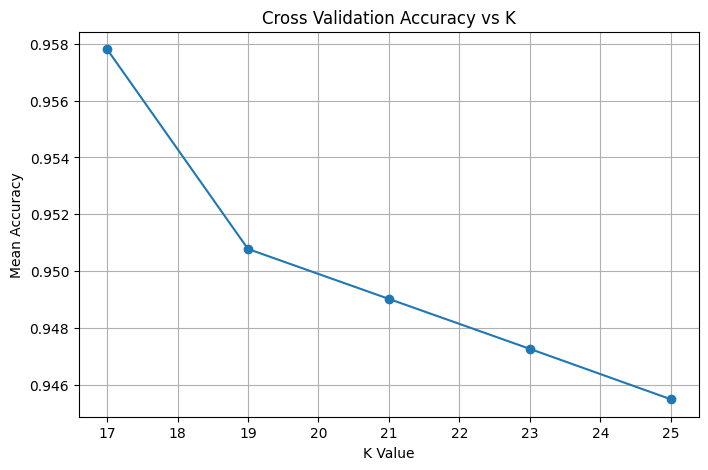


Comparison of Train-Test Split and Cross Validation
   K Value  Train-Test Accuracy  Cross Validation Accuracy
0       17             0.938596                   0.957802
1       19             0.938596                   0.950784
2       21             0.938596                   0.949030
3       23             0.938596                   0.947275
4       25             0.947368                   0.945505

Heuristic K : 21
Best K (Train-Test Split) : 25
Best K (Cross Validation) : 17

Final Selected K: 17 (Selected based on better validation performance)


In [8]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 5-Fold Cross Validation
# --------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# K values around heuristic K
k_values = []

for k in range(max(1, heuristic_k-5), heuristic_k+6):
    if k % 2 != 0:
        k_values.append(k)

cv_accuracy = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_scaled,
        y,
        cv=cv,
        scoring='accuracy'
    )

    cv_accuracy.append(scores.mean())

# Results Table
cv_results = pd.DataFrame({
    "K Value": k_values,
    "Mean Cross Validation Accuracy": cv_accuracy
})

print(cv_results)

# Best K
best_cv_k = k_values[np.argmax(cv_accuracy)]

print("\nBest K from Cross Validation:", best_cv_k)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_accuracy, marker='o')
plt.title("Cross Validation Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Mean Accuracy")
plt.grid(True)
plt.show()

# --------------------------------------------------
# Compare with Train-Test Results
# --------------------------------------------------

comparison = pd.DataFrame({
    "K Value": result["K Value"],
    "Train-Test Accuracy": result["Accuracy"],
    "Cross Validation Accuracy": cv_accuracy
})

print("\nComparison of Train-Test Split and Cross Validation")
print(comparison)

print("\nHeuristic K :", heuristic_k)
print("Best K (Train-Test Split) :", best_k)
print("Best K (Cross Validation) :", best_cv_k)

if best_cv_k == best_k:
    print("\nFinal Selected K:", best_cv_k)
else:
    print("\nFinal Selected K:", best_cv_k, "(Selected based on better validation performance)")

# Task 5: Classification Evaluation

### Approach

The final KNN classifier was trained using the optimal value of **K** obtained from the heuristic method and cross-validation. The model was then evaluated using standard classification metrics to assess its predictive performance.

The following evaluation metrics were computed:

- **Accuracy** measures the overall proportion of correctly classified instances.
- **Precision** measures how many of the samples predicted as positive are actually positive.
- **Recall** measures how many of the actual positive samples are correctly identified.
- **F1 Score** is the harmonic mean of Precision and Recall, providing a balanced evaluation when class distributions are uneven.
- **Confusion Matrix** summarizes the number of correct and incorrect predictions for each class.
- **ROC Curve (Receiver Operating Characteristic Curve)** illustrates the trade-off between the True Positive Rate and False Positive Rate at different classification thresholds.
- **AUC (Area Under the ROC Curve)** measures the classifier's ability to distinguish between the two classes. An AUC value closer to 1 indicates excellent classification performance.

Accuracy : 0.9386
Precision: 0.973
Recall   : 0.8571
F1 Score : 0.9114


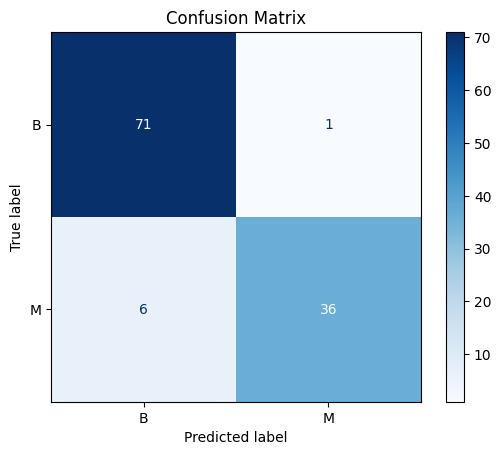

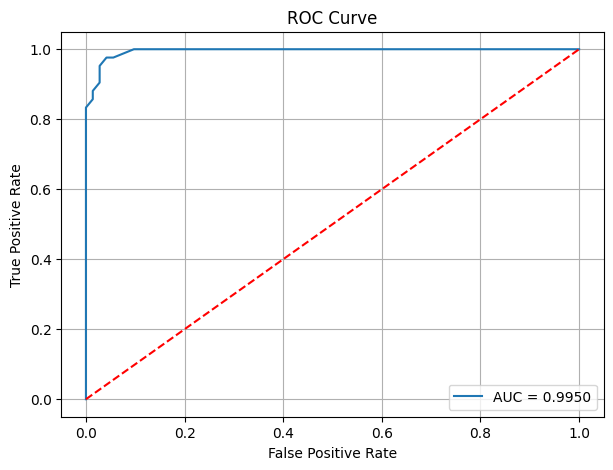

AUC Score : 0.995


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Encode Target Variable
# ----------------------------------------------------

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------------------------------
# Train Final Model
# ----------------------------------------------------

final_model = KNeighborsClassifier(n_neighbors=best_cv_k)

final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)

# Prediction Probabilities
y_prob = final_model.predict_proba(X_test)[:,1]

# ----------------------------------------------------
# Evaluation Metrics
# ----------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

# ----------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ----------------------------------------------------
# ROC Curve
# ----------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score :", round(auc,4))

# Task 6: Comparative Study with Regression (Lab 3 Integration)

### Approach

The evaluation metrics used in Linear Regression and KNN Classification were compared to understand how model performance is measured for different machine learning tasks.

Regression metrics such as **MAE, MSE, RMSE, and R² Score** measure the magnitude of prediction errors for continuous numerical outputs. In contrast, classification metrics such as **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC** evaluate how correctly the model assigns observations to predefined classes.

The comparison highlights the difference between error-based evaluation used in regression and decision-based evaluation used in classification. This analysis helps identify why different evaluation techniques are required depending on the nature of the prediction problem.

In [10]:
import pandas as pd

# -------------------------------------------------------
# Comparison of Regression and Classification Metrics
# -------------------------------------------------------

comparison = pd.DataFrame({
    "Aspect": [
        "Primary Objective",
        "Prediction Type",
        "Evaluation Logic",
        "R² Score vs Accuracy",
        "RMSE vs F1 Score",
        "MAE vs Confusion Matrix"
    ],

    "Regression (Lab 3)": [
        "Predict continuous numerical values",
        "Continuous Output",
        "Measures prediction error",
        "R² measures goodness of fit between predicted and actual values.",
        "RMSE measures average prediction error in original units.",
        "MAE measures average absolute error."
    ],

    "Classification (KNN Lab)": [
        "Predict categorical classes",
        "Discrete Class Labels",
        "Measures correctness of classification decisions",
        "Accuracy measures percentage of correctly classified samples.",
        "F1 Score balances Precision and Recall for classification.",
        "Confusion Matrix shows TP, TN, FP and FN."
    ]
})

print(comparison)

# -------------------------------------------------------
# Difference in Evaluation Logic
# -------------------------------------------------------

evaluation_logic = pd.DataFrame({

    "Task": [
        "Continuous Prediction",
        "Classification"
    ],

    "Evaluation Logic": [
        "Evaluates how close predicted numerical values are to actual values using error-based metrics.",
        "Evaluates whether each prediction belongs to the correct class using decision-based metrics."
    ]

})

print("\nEvaluation Logic")
print(evaluation_logic)

                    Aspect                                 Regression (Lab 3)  \
0        Primary Objective                Predict continuous numerical values   
1          Prediction Type                                  Continuous Output   
2         Evaluation Logic                          Measures prediction error   
3     R² Score vs Accuracy  R² measures goodness of fit between predicted ...   
4         RMSE vs F1 Score  RMSE measures average prediction error in orig...   
5  MAE vs Confusion Matrix               MAE measures average absolute error.   

                            Classification (KNN Lab)  
0                        Predict categorical classes  
1                              Discrete Class Labels  
2   Measures correctness of classification decisions  
3  Accuracy measures percentage of correctly clas...  
4  F1 Score balances Precision and Recall for cla...  
5          Confusion Matrix shows TP, TN, FP and FN.  

Evaluation Logic
                    Task     

# Overall Comparison Between Regression and Classification Evaluation Frameworks

Regression and classification are supervised machine learning techniques designed to solve different types of prediction problems. Regression predicts continuous numerical values, whereas classification predicts discrete class labels.

Regression evaluation focuses on measuring the magnitude of prediction errors using metrics such as MAE, MSE, RMSE, and R² Score. Lower error values and higher R² indicate better predictive performance.

Classification evaluation focuses on measuring how correctly a model classifies observations using metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. These metrics assess the quality of classification decisions rather than numerical prediction errors.

In healthcare applications such as breast cancer diagnosis, Recall and ROC-AUC are more important than Accuracy because missing a cancer patient (False Negative) can have severe consequences. Therefore, classification evaluation emphasizes correct identification of positive cases in addition to overall accuracy.

# Task 7: Analytical Questions

### 1. Why is KNN called a lazy learning algorithm?

KNN is called a lazy learning algorithm because it does not build a model during the training phase. Instead, it stores the training data and performs computations only when a new instance needs to be classified.

---

### 2. Why is feature scaling required in KNN?

KNN uses distance calculations to identify the nearest neighbors. Features with larger numerical values dominate the distance calculation if scaling is not applied. Standardization ensures that all features contribute equally.

---

### 3. Explain heuristic K selection using √n rule.

The heuristic rule selects the initial value of K as:

**K = √n**

where **n** is the number of training samples. The nearest odd integer is usually selected to avoid ties. This provides a reasonable starting point before optimization.

---

### 4. Why is cross-validation more reliable than a single train-test split?

Cross-validation evaluates the model using multiple training and testing combinations, reducing bias caused by a particular split and providing a more reliable estimate of model performance.

---

### 5. How does K affect the bias-variance trade-off?

A small K creates a complex model with low bias and high variance, which may lead to overfitting. A large K creates a simpler model with high bias and low variance, which may lead to underfitting.

---

### 6. Why is recall more important than accuracy in cancer prediction?

Recall measures how many actual cancer cases are correctly identified. Missing a cancer patient (False Negative) is much more dangerous than incorrectly predicting cancer in a healthy patient. Therefore, recall is more important in medical diagnosis.

---

### 7. What is the limitation of very large K values?

Very large K values include many distant neighbors during classification, causing the model to oversimplify the decision boundary. This increases bias and may reduce classification accuracy due to underfitting.

# Conclusion

The heuristic √n rule provided an effective starting point for selecting the K value, while cross-validation identified the optimal K by evaluating multiple training and testing combinations. Comparing different train-test splits demonstrated that model performance remained relatively stable, indicating good generalization capability.

The KNN classifier achieved strong performance based on Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. Among these metrics, Recall and ROC-AUC were especially important for breast cancer prediction because correctly identifying positive cases is critical in healthcare applications.

Unlike Linear Regression, which evaluates prediction errors using MAE, MSE, RMSE, and R² Score, KNN Classification evaluates the correctness of classification decisions. This lab established a clear understanding of the differences between regression and classification evaluation techniques and demonstrated the importance of selecting appropriate evaluation metrics based on the prediction task.